# Fine-tuning Qwen2.5-1.5B on GSM8K with LoRA: does it actually help?

**Question this notebook answers:** if we LoRA fine-tune `Qwen2.5-1.5B-Instruct`
on GSM8K's training rationales, does its accuracy on held-out GSM8K math
problems go up, and by how much can we actually claim to have measured?

**Method, in one paragraph:** load the base model once; score it, pristine, on
400 held-out test problems it has never been trained on; fine-tune a LoRA
adapter on the official GSM8K train split; reload the adapter *from disk* (not
the in-memory trained object) and score the same 400 problems again; then
compare the two scores with paired statistics (not just a bare percentage
difference), because both models are being asked the exact same questions.
Overfitting is watched for directly, via the train/dev loss curve in Section 12
and 17 plus early stopping -- not inferred indirectly.

**Two things worth knowing before you read a number out of this notebook:**

1. GSM8K is one of the most widely used math instruction-tuning datasets in
   existence, and `Qwen2.5-1.5B-Instruct` was already instruction-tuned before
   we ever touch it. It is likely the base model has already seen data very
   similar to (if not overlapping) what we're about to fine-tune on. So this
   notebook is not really testing "can LoRA teach a model new math" -- it's
   testing "does adapting the model to *this exact answer format and style*
   change its measured accuracy." That's a real and useful question, just a
   narrower one than "did we make it better at math."
2. GSM8K's gold rationales are short and terse (mean ~90 tokens). Qwen's own
   native chain-of-thought on these problems tends to run longer. Training on
   short rationales could easily make the model *more* format-compliant but
   *not more accurate* -- or even less accurate, if it starts truncating its
   own reasoning to match the terse training style. A flat or negative result
   here is a legitimate, useful finding, not a bug in the notebook. (An earlier
   run measured exactly this: fine-tuning cut mean generation length from 275
   to 86 tokens and accuracy from 69.5% to 44%. `EPOCHS=1` and a lower
   `LEARNING_RATE` in Section 3 exist specifically to keep this run inside the
   window where format compliance is learned before reasoning collapses.)


## 1. Dependencies

In [15]:
import sys

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)


Running in Colab: False


### CUDA-enabled torch (local machines only)

Colab's runtime already ships a CUDA-enabled torch, so there's nothing to do
there. On a local machine, `pip` can silently install (or leave in place) a
**CPU-only** build of torch, which this whole notebook needs to not do --
everything downstream assumes a GPU.

The cell below installs the CUDA 13.2 wheels, which match driver-reported
CUDA 13.3 (minor-version skew between the driver and the wheel's CUDA runtime
is expected and fine). **If this cell actually installs something, restart the
kernel before continuing** -- the already-imported CPU build otherwise stays
in memory for the rest of the session.


In [16]:
if not IN_COLAB:
    %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132
else:
    print("Colab already ships a CUDA-enabled torch -- skipping reinstall.")


Looking in indexes: https://download.pytorch.org/whl/cu132
Note: you may need to restart the kernel to use updated packages.


In [17]:
# The rest of the stack, both environments. Notably absent: `bitsandbytes` and
# `trl`. We don't need bitsandbytes because we train in bf16/fp16 rather than
# 4-bit (see the USE_4BIT note in Configuration, below) -- it's the source of
# the fragile installs and Windows file-lock errors in the original version of
# this notebook. We don't need trl because we build training examples by hand
# with explicit label masking (see Section 10), which keeps the exact string a
# model is trained on fully visible in this notebook rather than hidden inside
# a training-framework's internal templating.
%pip install -q -U transformers datasets peft accelerate matplotlib


Note: you may need to restart the kernel to use updated packages.


## 2. Environment

In [18]:
import os, re, sys, json, math, time, gc

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
# Must be set before `import torch` initializes CUDA. Reduces allocator
# fragmentation, which can otherwise cause a near-full-VRAM allocation to
# fail (or silently spill to slow system-memory fallback, see Section 3) even
# when enough memory is technically free across smaller unused blocks.

from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed,
)
from peft import LoraConfig, get_peft_model, TaskType

IN_COLAB = "google.colab" in sys.modules

assert torch.cuda.is_available(), (
    "No CUDA device visible to torch. If you're on a local machine, install the "
    "CUDA build and RESTART THE KERNEL:\n"
    "  %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132"
)

SUPPORTS_BF16 = torch.cuda.is_bf16_supported()
COMPUTE_DTYPE = torch.bfloat16 if SUPPORTS_BF16 else torch.float16


def gpu_mem():
    return (f"{torch.cuda.memory_allocated()/1e9:.2f} GB allocated / "
            f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")


print(f"torch:          {torch.__version__}")
print(f"Device:         {torch.cuda.get_device_name(0)}")
print(f"VRAM:           {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"bf16 support:   {SUPPORTS_BF16}")
print(f"Compute dtype:  {COMPUTE_DTYPE}")
print(f"In Colab:       {IN_COLAB}")

torch:          2.13.0+cu132
Device:         NVIDIA GeForce RTX 3080 Ti Laptop GPU
VRAM:           17.2 GB
bf16 support:   True
Compute dtype:  torch.bfloat16
In Colab:       False


## 3. Configuration

Every path and hyperparameter lives here, in one place, so a re-run with
different settings never means hunting through the notebook.


In [19]:
SMOKE = False
# True -> a tiny end-to-end run (a few dozen examples, a handful of training
# steps) that exercises every cell in under a couple of minutes, to catch a
# broken cell before committing to a real run. The accuracy numbers it
# produces are meaningless (too few examples) -- it only proves the plumbing
# works. Flip back to False for a real run.

SEED = 0
BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

N_VAL  = 16 if SMOKE else 400    # held out from *train*, used only for the eval-loss curve
N_EVAL = 16 if SMOKE else 400    # drawn from the official *test* split -- the headline comparison
# Both raised from 200. N_EVAL is the one that matters: at n=200 the 95% Wilson
# interval on a ~68% accuracy is +/-6.4 pp and the paired McNemar test cannot
# resolve a difference smaller than ~12 pp, so "fine-tuned matches base" was not a
# claim this notebook could actually support. At n=400 those become +/-4.6 pp and
# ~8.7 pp (and ~4 pp once the two models agree more often). N_VAL=400 mainly just
# steadies the dev-loss curve; it was already converged to four decimals at 200.
# Both fit: the official splits hold 7,473 train and 1,319 test examples, and
# Section 5 asserts dev/train/test stay disjoint.
N_TRAIN_CAP = 64 if SMOKE else 2000   # cap on training examples (None = everything left after the N_VAL holdout)

EPOCHS = 1 if SMOKE else 2
# Two passes over the 2,000 training examples = 500 optimizer steps (see
# GRAD_ACCUM below). Raised from 1 for the loss curve's sake: over a single
# epoch dev loss only ever falls and flattens, so there is no divergence to
# see and no way to judge overfitting from the plot. Whatever separation
# between train and dev loss exists shows up in the second pass, when the
# model starts seeing examples it has already fitted.
# The risk this reopens, stated plainly: a prior run at 3 epochs / LR 1e-4
# (375 steps) collapsed fine-tuned accuracy 69.5% -> 44% by teaching the
# model to imitate GSM8K's terse gold rationale instead of its own longer
# chain of thought (mean generation length 275 -> 86 tokens). Format
# compliance itself is learned almost immediately -- a smoke run hit 43.8%
# '####' compliance after 4 optimizer steps -- so everything after that is
# spent rewriting the reasoning policy. This run's 5x lower learning rate is
# the counterweight; the `mean new tokens` and `mean reasoning lines` columns
# in Section 16 are how you check whether it held.
LEARNING_RATE = 2e-5
# Lowered from 1e-4. A LoRA update's functional perturbation scales roughly
# with (alpha/r) times the summed learning rate, so this 5x cut is the main
# brake on weight drift relative to the run that collapsed.
BATCH_SIZE = 2
GRAD_ACCUM = 4
# Effective batch 2 x 4 = 8, so 2,000 examples is 250 optimizer steps per
# epoch and 500 over the run. A smaller effective batch buys a longer, denser
# x-axis for the loss plot at the same total compute; the per-step loss is
# correspondingly noisier, which Section 17 handles by plotting a rolling
# mean over the raw points rather than by logging less often.
MAX_LENGTH = 384     # lowered from 448 to cap the worst-case per-batch memory spike --
                        # dynamic padding pads to the batch's longest member, so one
                        # unusually long example still sets memory usage for the whole
                        # batch. 384 still comfortably covers the typical example (measured
                        # mean ~200 tokens); only the longest tail gets truncated.
MAX_NEW_TOKENS = 640     # raised from 400: 72/200 base generations were being cut off at
                          # 400 (28 of those scored wrong as a result), understating base
                          # accuracy. 640 comfortably covers base's measured generation
                          # lengths so neither model is truncated -- applied to both, so the
                          # comparison stays fair.
GEN_BATCH_SIZE = 16      # batched greedy-generation batch size (see Section 8 for the memory math).
                          # Lowered from 32 to keep worst-case KV-cache/prefill memory well
                          # under the GPU's 16GB limit during the two test-set eval passes.

LORA_R = 16
LORA_ALPHA = 32
# alpha/r = 2.0, i.e. twice the scaling of PEFT's own alpha == r convention,
# so each step moves the effective weights twice as far. This and
# LEARNING_RATE are the same lever pulled in opposite directions; if this run
# collapses generation length again, halving alpha to 16 is the cheaper thing
# to try first, since it costs no extra training time.
LORA_DROPOUT = 0.1
# A bit of dropout on the LoRA path is cheap insurance
# against memorizing the 2,000-example training slice.
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",      # attention
    "gate_proj", "up_proj", "down_proj",          # MLP -- style/format adaptation happens here too
]

USE_4BIT = False
# Qwen2.5-1.5B fits comfortably in bf16 on any 16GB+ GPU (~3.1GB of weights), so
# 4-bit quantization -- a *memory* optimization -- isn't needed here, and it
# actively costs speed (every forward pass has to dequantize) and blocks a
# clean `merge_and_unload()` into a standalone model. Flip this on only if you
# scale up to a much larger model that doesn't fit otherwise.
GRAD_CHECKPOINTING = True   # recomputes activations during backward instead of storing them --
                            # ~20-30% slower per step, but substantially cuts activation memory
                            # (the dominant consumer once training starts). Enabled after an
                            # earlier run on this machine crept up to ~98% VRAM use and
                            # collapsed into Windows' silent CUDA-to-system-memory fallback.

SAVE_MERGED = False   # Section 15's merge_and_unload() writes a ~3.1GB standalone model and,
                      # as a side effect, permanently mutates `peft_model`'s base layers in
                      # place -- not needed day-to-day since the adapter + base model
                      # (Section 19) is sufficient to reproduce every result here. Flip on
                      # only when you actually need a peft-free standalone checkpoint.

SYSTEM_PROMPT = (
    "You are a careful math assistant. Solve the problem step by step, then "
    "give the final numeric answer on its own last line in exactly this "
    "form:\n#### <number>"
)
# Pinned explicitly rather than left blank: Qwen's chat template silently
# substitutes its own default system message ("You are Qwen, created by
# Alibaba Cloud...") when none is given. Leaving it unpinned would mean the
# exact prompt text depends on whichever default the template ships with --
# pin it so training and eval are guaranteed to share the same prompt.

OUTPUT_ROOT = (
    "/content/drive/MyDrive/algoverse/gsm8k_lora"
    if IN_COLAB and os.path.exists("/content/drive")
    else "./models/qwen2.5-1.5b-gsm8k-lora"
)
ADAPTER_DIR = os.path.join(OUTPUT_ROOT, "adapter")
MERGED_DIR  = os.path.join(OUTPUT_ROOT, "merged")
RESULTS_DIR = os.path.join(OUTPUT_ROOT, "results")
for d in (ADAPTER_DIR, MERGED_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

set_seed(SEED)
print(f"SMOKE test mode: {SMOKE}")
print(f"Output root:     {OUTPUT_ROOT}")

SMOKE test mode: False
Output root:     ./models/qwen2.5-1.5b-gsm8k-lora


## 4. Load the tokenizer and base model -- once

This is the *only* place the base model is loaded. Every section below --
baseline scoring, LoRA training, and the final post-training scoring -- reuses
these same two objects, so there's no risk of accidentally comparing two
subtly different model instances.


In [20]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)
# Qwen2.5 already ships a distinct pad token (<|endoftext|>), separate from its
# eos token (<|im_end|>). Unlike some Llama-family checkpoints, there's no need
# to alias pad_token = eos_token here -- doing so (as the original version of
# this notebook did) makes padded positions indistinguishable from a genuine
# end-of-sequence token, and is exactly what produced the "PAD/BOS/EOS tokens
# differ from the model config" warning in that version.
print(f"pad_token: {tokenizer.pad_token!r} ({tokenizer.pad_token_id})")
print(f"eos_token: {tokenizer.eos_token!r} ({tokenizer.eos_token_id})")

quantization_config = None
if USE_4BIT:
    from transformers import BitsAndBytesConfig
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=COMPUTE_DTYPE,
        bnb_4bit_use_double_quant=True,
    )

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    dtype=COMPUTE_DTYPE,
    quantization_config=quantization_config,
    device_map={"": 0},
)
base_model.config.use_cache = True

print(f"\nLoaded {BASE_MODEL_ID} in {COMPUTE_DTYPE}.")
print(f"Memory: {gpu_mem()}")


pad_token: '<|endoftext|>' (151643)
eos_token: '<|im_end|>' (151645)


Loading weights: 100%|██████████| 338/338 [00:00<00:00, 345.69it/s]



Loaded Qwen/Qwen2.5-1.5B-Instruct in torch.bfloat16.
Memory: 6.49 GB allocated / 9.69 GB reserved


## 5. Data

We use GSM8K's **official** train and test splits -- not a hand-rolled split
of the train set, which is what the original version of this notebook did
(leaving the real 1319-example test split completely unused). A fixed seed
makes the sampling reproducible.


In [21]:
raw_train = load_dataset("openai/gsm8k", "main", split="train")
raw_test  = load_dataset("openai/gsm8k", "main", split="test")
print(f"Official train split: {len(raw_train)} | Official test split: {len(raw_test)}")

shuffled_train = raw_train.shuffle(seed=SEED)
dev_rows   = shuffled_train.select(range(N_VAL))
train_rows = shuffled_train.select(range(N_VAL, len(shuffled_train)))
if N_TRAIN_CAP is not None:
    train_rows = train_rows.select(range(min(N_TRAIN_CAP, len(train_rows))))

test_rows = raw_test.shuffle(seed=SEED).select(range(min(N_EVAL, len(raw_test))))

# Defensive check: the headline eval set must never share a question with
# what the model was trained on.
assert set(train_rows["question"]).isdisjoint(test_rows["question"])
assert set(dev_rows["question"]).isdisjoint(test_rows["question"])

print(f"train {len(train_rows)} (fine-tuning)")
print(f"dev   {len(dev_rows)} (held out from train, eval-loss curve only)")
print(f"test  {len(test_rows)} (official test split, headline comparison)")

print(f"\n--- sample gold answer ---\n{train_rows[0]['answer']}")


Official train split: 7473 | Official test split: 1319
train 2000 (fine-tuning)
dev   400 (held out from train, eval-loss curve only)
test  400 (official test split, headline comparison)

--- sample gold answer ---
On Tuesday, Adam bought 3 * 15 apples = <<3*15=45>>45 apples.
On Wednesday, Adam bought 4 * 45 apples = <<4*45=180>>180 apples.
Adam bought 15 apples + 45 apples + 180 apples = <<15+45+180=240>>240 apples on the three days.
#### 240


## 6. Prompt format -- the fairness problem

`Qwen2.5-1.5B-Instruct` is *already* a capable instruction-tuned model on
grade-school math. If we trained on one prompt format (say, a custom
`### Instruction:` template) and then evaluated the *base* model in that same
unfamiliar format, most of the measured "improvement" would really be the base
model being handicapped by an alien prompt -- not the LoRA teaching it
anything.

**Resolution:** both models see the exact same prompt, built by the exact same
function (`to_chat_example`, below), using Qwen's own chat template with an
explicit, pinned system prompt. Because training examples are built by calling
this same function (Section 10), the training prompt and the eval prompt are
identical by construction -- there's no separate "training format" and "eval
format" that could quietly drift apart.


In [22]:
def to_chat_example(question: str) -> str:
    """Render one GSM8K question as a Qwen chat prompt, ready for generation.
    Reused for both training examples and every eval call below."""
    return tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
        ],
        tokenize=False,
        add_generation_prompt=True,
    )


# Demonstrate why the system prompt is pinned explicitly: this is what Qwen's
# template renders when no system message is given at all.
_unpinned = tokenizer.apply_chat_template(
    [{"role": "user", "content": "PROBE"}], tokenize=False, add_generation_prompt=True
)
print("Qwen's default when no system message is given:")
print(f"  {_unpinned!r}")
print("\nOur pinned version:")
print(f"  {to_chat_example('PROBE')!r}")


Qwen's default when no system message is given:
  '<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nPROBE<|im_end|>\n<|im_start|>assistant\n'

Our pinned version:
  '<|im_start|>system\nYou are a careful math assistant. Solve the problem step by step, then give the final numeric answer on its own last line in exactly this form:\n#### <number><|im_end|>\n<|im_start|>user\nPROBE<|im_end|>\n<|im_start|>assistant\n'


## 7. Answer extraction and scoring

GSM8K's gold answers always end with a `#### <integer>` line -- we verify that
below rather than assume it. Model generations are messier: they might follow
that convention, or might just state a number in prose. We use `Decimal`
rather than `float` for comparison so that `72` and `72.0` compare exactly
equal with no floating-point rounding involved.


In [23]:
CALC_RE = re.compile(r"<<[^>]*>>")
_NUM = r"-?(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d+)?"
HASH_RE = re.compile(r"####\s*\$?\s*(" + _NUM + r")")
NUM_RE  = re.compile(_NUM)


def clean_target(answer: str) -> str:
    """Strip GSM8K's inline <<calculator>> annotations from a training target,
    e.g. '48/2 = <<48/2=24>>24' -> '48/2 = 24'. These are a dataset-authoring
    artifact (a scratch-calculator trace), not something worth the model
    reproducing verbatim. Measured effect: they appear in ~99% of rationales
    and stripping them cuts mean target length by roughly 15%, which is a
    direct training- and generation-time saving. It does NOT change how
    reliably we can extract the final answer -- the '#### N' line they
    surround is untouched either way."""
    return CALC_RE.sub("", answer)


def to_decimal(s):
    """Parse a matched number string into a Decimal, tolerating '$', ',',
    '%', and a trailing period."""
    if s is None:
        return None
    s = s.strip().replace(",", "").replace("$", "").replace("%", "").rstrip(".")
    try:
        return Decimal(s)
    except InvalidOperation:
        return None


def extract_gold(answer: str) -> Decimal:
    m = HASH_RE.search(answer)
    assert m is not None, f"gold answer has no '#### N' line: {answer!r}"
    return to_decimal(m.group(1))


def extract_pred(text: str):
    """Pull the model's final numeric answer out of free-form generated
    text. Primary: the LAST '#### N' occurrence (a model that restates the
    question before answering could otherwise match the wrong one). Fallback:
    the last number anywhere in the text, for generations that never emit the
    '####' marker. Returns (value, method) -- `method` lets us report how
    often each model needed the less-reliable fallback."""
    hashes = list(HASH_RE.finditer(text))
    if hashes:
        v = to_decimal(hashes[-1].group(1))
        if v is not None:
            return v, "hash"
    nums = NUM_RE.findall(text)
    if nums:
        return to_decimal(nums[-1]), "last_number"
    return None, "none"


def is_correct(pred, gold) -> bool:
    return pred is not None and pred == gold


def n_reasoning_lines(text: str) -> int:
    """Non-empty lines before the first '#### N' -- a proxy for how much
    reasoning happened before the model committed to an answer, and the
    clearest single indicator of the length-collapse failure mode an earlier
    run suffered (mean reasoning lines dropped from 18.5 to 4.6 there)."""
    m = HASH_RE.search(text)
    head = text[: m.start()] if m else text
    return sum(1 for line in head.splitlines() if line.strip())


# Self-test against formats we've actually seen in real generations.
_cases = [
    ("blah blah #### 72", "72"),
    ("The total is $1,080 dollars.\n#### 1,080", "1080"),
    ("#### -5", "-5"),
    ("no marker, but the answer is 42 apples", "42"),
    ("nothing numeric here", None),
]
for text, expected in _cases:
    got, _ = extract_pred(text)
    want = Decimal(expected) if expected is not None else None
    assert got == want, (text, got, want)
print(f"extract_pred self-test passed ({len(_cases)} cases).")

assert all(extract_gold(a) is not None for a in raw_train["answer"][:500]), "unexpected gold format"
print("Gold-answer '#### N' format verified on a sample of the training set.")

extract_pred self-test passed (5 cases).
Gold-answer '#### N' format verified on a sample of the training set.


## 8. Batched generation and the shared evaluation harness

Defined **before** training, so the exact same `evaluate()` function scores
both the pristine base model and the fine-tuned model later -- no chance of
the two being measured differently.

Two details matter for batched generation with a decoder-only model:

- **`padding_side` must be `"left"` during generation.** Right-padding is
  correct for training, but at generation time it pushes real tokens away
  from position 0 for every prompt shorter than the batch's longest one,
  which corrupts position ids for anything but the single longest sequence in
  the batch. We flip it here and restore the original setting afterward.
- **Sorting prompts by length before batching** keeps each batch's members
  close in length, which minimizes wasted padding compute -- a batch's cost is
  set by its longest member. We restore the original order before returning.

Qwen2.5-1.5B in bf16 is ~3.1GB of weights; at `GEN_BATCH_SIZE=32` and a few
hundred tokens per sequence the KV cache adds well under 1GB (this model uses
grouped-query attention with only 2 KV heads), so generation has plenty of
headroom on a 16GB GPU.


In [24]:
def generate_batch(model, prompts, max_new_tokens=None, batch_size=None):
    """Greedy-decode a batch of prompts. Returns (texts, n_new_tokens),
    aligned to `prompts`."""
    max_new_tokens = max_new_tokens or MAX_NEW_TOKENS
    batch_size = batch_size or GEN_BATCH_SIZE

    original_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    model.eval()

    eos_ids = [tokenizer.eos_token_id]
    endoftext_id = tokenizer.convert_tokens_to_ids("<|endoftext|>")
    if endoftext_id is not None and endoftext_id not in eos_ids:
        eos_ids.append(endoftext_id)

    order = sorted(range(len(prompts)), key=lambda i: len(prompts[i]))
    texts = [None] * len(prompts)
    n_new_tokens = [0] * len(prompts)

    try:
        with torch.inference_mode():
            for start in range(0, len(order), batch_size):
                idx = order[start:start + batch_size]
                batch = [prompts[i] for i in idx]
                inputs = tokenizer(batch, return_tensors="pt", padding=True).to(model.device)
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,   # greedy -> reproducible
                    eos_token_id=eos_ids,
                    pad_token_id=tokenizer.pad_token_id,
                )
                new_tokens = out[:, inputs["input_ids"].shape[1]:]
                decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
                for i, ids, text in zip(idx, new_tokens, decoded):
                    texts[i] = text.strip()
                    n_new_tokens[i] = int((ids != tokenizer.pad_token_id).sum())
    finally:
        tokenizer.padding_side = original_side

    return texts, n_new_tokens


def evaluate(model, rows, tag, verbose_examples=3):
    """Score `model` against `rows` (a GSM8K-format dataset slice), using the
    SAME harness every time. Returns one DataFrame row per example."""
    torch.cuda.reset_peak_memory_stats()
    prompts = [to_chat_example(r["question"]) for r in rows]
    t0 = time.time()
    generations, n_new_tokens = generate_batch(model, prompts)
    elapsed = time.time() - t0

    records = []
    for row, gen, ntok in zip(rows, generations, n_new_tokens):
        gold = extract_gold(row["answer"])
        pred, method = extract_pred(gen)
        records.append({
            "question": row["question"],
            "gold": gold,
            "prediction": gen,
            "pred_value": pred,
            "pred_method": method,
            "n_new_tokens": ntok,
            "n_reasoning_lines": n_reasoning_lines(gen),
            "correct": is_correct(pred, gold),
        })
    df = pd.DataFrame(records)
    acc = df["correct"].mean()
    compliance = (df["pred_method"] == "hash").mean()
    print(f"{tag}: {df['correct'].sum()}/{len(df)} correct = {acc:.1%}  |  "
          f"'####' compliance {compliance:.1%}  |  "
          f"mean {df['n_new_tokens'].mean():.0f} new tokens  |  "
          f"mean {df['n_reasoning_lines'].mean():.1f} reasoning lines  |  "
          f"{elapsed:.0f}s ({elapsed/len(df):.2f}s/example)  |  "
          f"peak {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

    for _, r in df.head(verbose_examples).iterrows():
        flag = "correct" if r["correct"] else "wrong"
        print(f"  [{flag}] gold={r['gold']}  pred={r['pred_value']}  (via {r['pred_method']})")

    return df

## 9. Score the pristine base model

This runs against `base_model` before any LoRA adapter exists -- no ambiguity
about whether we're seeing base or fine-tuned behavior.


In [25]:
print("Scoring the PRISTINE base model (no adapter attached) ...\n")
base_df = evaluate(base_model, test_rows, tag="BASE MODEL")
base_acc = base_df["correct"].mean()


Scoring the PRISTINE base model (no adapter attached) ...

BASE MODEL: 275/400 correct = 68.8%  |  '####' compliance 0.2%  |  mean 281 new tokens  |  mean 19.3 reasoning lines  |  404s (1.01s/example)  |  peak 6.96 GB
  [correct] gold=400  pred=400  (via last_number)
  [wrong] gold=25  pred=37.5  (via last_number)
  [correct] gold=3  pred=3  (via last_number)


## 10. Build the training set

Each example is `to_chat_example(question)` (the *same* function used for
eval) followed by the cleaned answer and an explicit end-of-sequence token,
with the prompt span masked out of the loss (`-100`) so the model is only ever
trained to predict the answer, never to reproduce the question.


In [26]:
def build_example(question, answer):
    """Return (input_ids, labels) for one training example."""
    prompt = to_chat_example(question)
    target = clean_target(answer)
    full_text = prompt + target + tokenizer.eos_token

    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"][:MAX_LENGTH]

    n_masked = min(len(prompt_ids), len(full_ids))
    labels = [-100] * n_masked + full_ids[n_masked:]
    return full_ids, labels


# Guard: the prompt must be a clean token prefix of the full sequence, or the
# -100 mask above would silently land on the wrong tokens (e.g. if the
# tokenizer merged a token across the prompt/answer boundary).
_probe_q = train_rows[0]["question"]
_probe_prompt = to_chat_example(_probe_q)
_probe_ids = tokenizer(_probe_prompt, add_special_tokens=False)["input_ids"]
_probe_full = tokenizer(
    _probe_prompt + clean_target(train_rows[0]["answer"]) + tokenizer.eos_token,
    add_special_tokens=False,
)["input_ids"]
assert _probe_full[:len(_probe_ids)] == _probe_ids, (
    "Prompt is not a clean token prefix of the full sequence -- label masking would misalign."
)
print("Prompt/answer token boundary verified clean.")

train_examples = [build_example(r["question"], r["answer"]) for r in train_rows]
dev_examples   = [build_example(r["question"], r["answer"]) for r in dev_rows]

lengths = [len(ids) for ids, _ in train_examples]
print(f"\n{len(train_examples)} training examples | "
      f"length mean {np.mean(lengths):.0f}, p95 {np.percentile(lengths, 95):.0f}, "
      f"max {max(lengths)} tokens (cap {MAX_LENGTH})")


def to_hf_dataset(examples):
    return Dataset.from_dict({
        "input_ids": [ids for ids, _ in examples],
        "labels":    [labels for _, labels in examples],
    })


train_dataset = to_hf_dataset(train_examples)
dev_dataset   = to_hf_dataset(dev_examples)

# Pads each batch to its own longest member (not to MAX_LENGTH), and pads
# labels with -100 so padding never contributes to the loss.
data_collator = DataCollatorForSeq2Seq(tokenizer, padding=True, label_pad_token_id=-100)

# Sanity check the mask on one example: prompt masked, answer supervised.
_ids0, _labels0 = train_examples[0]
_n_masked = sum(1 for l in _labels0 if l == -100)
print(f"\nExample 0: {len(_ids0)} tokens, {_n_masked} masked (prompt), "
      f"{len(_ids0) - _n_masked} supervised (answer)")


Prompt/answer token boundary verified clean.

2000 training examples | length mean 200, p95 310, max 384 tokens (cap 384)

Example 0: 163 tokens, 92 masked (prompt), 71 supervised (answer)


## 11. Attach the LoRA adapter

Targets both attention (`q/k/v/o_proj`) and the MLP (`gate/up/down_proj`).
Attention-only adapters are common, but the MLP is where a lot of a
transformer's format- and style-level behavior lives, and that's the main
thing we expect this fine-tune to change.


In [27]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
)

peft_model = get_peft_model(base_model, lora_config)
peft_model.enable_input_require_grads()
peft_model.print_trainable_parameters()

# LoRA params must stay in fp32 for optimizer updates of size (lr * grad) to
# not round away against a bf16/fp16 base -- PEFT does this by default, but
# check rather than assume.
trainable_dtypes = {p.dtype for p in peft_model.parameters() if p.requires_grad}
print(f"Trainable parameter dtypes: {trainable_dtypes}")
assert trainable_dtypes == {torch.float32}, "expected all trainable (LoRA) params in fp32"


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
Trainable parameter dtypes: {torch.float32}


## 12. Train

`bf16`/`fp16` is chosen automatically from what the GPU supports (Section 2). Gradient checkpointing
is on (Section 3) -- trading ~20-30% more compute time per step for substantially lower activation
memory, after an earlier run on this machine crept up to ~98% VRAM usage and collapsed into
Windows' silent CUDA-to-system-memory fallback. 4-bit quantization is still skipped: it would save
more memory but costs even more speed and blocks a clean `merge_and_unload()`.

**Logging cadence.** The training loss is logged at *every* optimizer step (`logging_steps=1`),
which over 500 steps gives the densest curve the `Trainer` can produce. The honest caveat: each of
those points is the loss on a single batch of 8 examples, so the raw series is genuinely jagged --
that is real variance in the data, not a plotting artifact, and Section 17 draws both the raw
points and a rolling mean rather than hiding it. Dev loss is evaluated ~25 times across the run
(`eval_on_start=True` adds a point at step 0, before any weight has moved, which anchors the curve).
Each dev evaluation is a full teacher-forced pass over all 400 held-out examples, so the eval
cadence is a straight time-for-resolution trade.

`load_best_model_at_end` tracks whichever checkpoint had the lowest `dev` loss and restores *that*
one when training finishes, rather than whatever the final step happens to be.
`EarlyStoppingCallback` is deliberately given a **loose** patience here -- roughly a quarter of the
run's worth of non-improvement. At the usual patience of 3 it would halt shortly after dev loss
first turned upward, cutting off exactly the divergence the second epoch exists to show; and
because `load_best_model_at_end` restores the best checkpoint regardless, letting training run
longer costs accuracy nothing, only time.

One caveat worth stating plainly: dev loss measures how closely the model imitates GSM8K's terse
gold text, which is the same behavior that caused the earlier collapse -- so it is a real but
imperfect proxy for "is this checkpoint good," not a guarantee. Section 16's `mean new tokens` and
`mean reasoning lines` columns are what actually show whether the collapse recurred. Neither the
loss-based selection nor early stopping plays any role in the final accuracy comparison, which is
scored only on `test`.

In [28]:
gc.collect()
torch.cuda.empty_cache()
print(f"Memory before training: {gpu_mem()}")

effective_batch = BATCH_SIZE * GRAD_ACCUM
steps_per_epoch = max(1, -(-len(train_dataset) // effective_batch))   # ceil division
total_steps = steps_per_epoch * EPOCHS
warmup_steps = max(1, int(0.1 * total_steps))

logging_steps = 1
# Log the training loss at every single optimizer step. This is what gives the
# Section 17 curve its resolution; the cost is one extra dict appended to
# trainer.state.log_history per step, which is negligible. Every eval step is
# trivially also a logging step, so no eval row in the progress table can read
# "No log" the way it did when logging_steps was larger than eval_steps.

eval_steps = max(1, total_steps // 25)
# ~25 dev-loss points spread across the whole run, regardless of how long it is.
# Each one is a full teacher-forced pass over all N_VAL dev examples, so halving
# this doubles the time spent evaluating -- this is the resolution/time knob.

early_stopping_patience = max(3, (total_steps // 4) // eval_steps)
# Deliberately loose: tolerate about a quarter of the run's length without
# improvement before stopping. The default patience of 3 would halt ~3 evals
# after dev loss first turns upward, truncating the very divergence the second
# epoch exists to show. load_best_model_at_end still restores the lowest-dev-loss
# checkpoint either way, so running longer costs accuracy nothing, only time.

print(f"{len(train_dataset)} examples | micro-batch {BATCH_SIZE} x accum {GRAD_ACCUM} "
      f"= effective batch {effective_batch}")
print(f"{total_steps} total steps ({steps_per_epoch}/epoch x {EPOCHS} epochs), {warmup_steps} warmup")
print(f"log every {logging_steps} step -> {total_steps} train-loss points")
print(f"dev eval every {eval_steps} steps -> ~{total_steps // eval_steps + 1} dev-loss points "
      f"({len(dev_dataset)} examples each)")
print(f"early-stopping patience {early_stopping_patience} evals "
      f"(~{early_stopping_patience * eval_steps} steps)\n")

training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_ROOT, "checkpoints"),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,      # kept equal to the train batch size -- a larger
                                                # eval batch materializes a much bigger fp32
                                                # logits tensor per step and was the direct
                                                # cause of an earlier VRAM-limit run
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=GRAD_CHECKPOINTING,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    logging_steps=logging_steps,
    eval_strategy="steps",
    eval_steps=eval_steps,
    eval_on_start=True,             # one dev-loss point at step 0, before any weight has moved --
                                    # the anchor the rest of the curve is read against
    save_strategy="steps",
    save_steps=eval_steps,          # must match eval_steps for load_best_model_at_end
    save_total_limit=2,             # keep disk usage bounded to the 2 most relevant checkpoints
    save_only_model=True,           # skip the ~148MB optimizer.pt per checkpoint
    load_best_model_at_end=True,    # restore the lowest-dev-loss checkpoint, not just the last step
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=SUPPORTS_BF16,
    fp16=not SUPPORTS_BF16,
    optim="adamw_torch",
    report_to="none",
    seed=SEED,
    dataloader_drop_last=False,
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    # Patience computed above -- loose on purpose, so the full curve gets drawn.
    # `load_best_model_at_end` restores the true lowest-dev-loss checkpoint
    # regardless of how long training continues past it.
    callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)],
)

torch.cuda.reset_peak_memory_stats()   # so the peak printed below is this phase's, not
                                       # the base-model eval pass's

print("Training...")
train_result = trainer.train()

print(f"\nFinal training loss: {train_result.training_loss:.4f}")
print(f"Peak memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

Memory before training: 6.57 GB allocated / 6.95 GB reserved
2000 examples | micro-batch 2 x accum 4 = effective batch 8
500 total steps (250/epoch x 2 epochs), 50 warmup
log every 1 step -> 500 train-loss points
dev eval every 20 steps -> ~26 dev-loss points (400 examples each)
early-stopping patience 6 evals (~120 steps)

Training...


Step,Training Loss,Validation Loss
0,No log,0.596031
20,0.523807,0.560231
40,0.457510,0.480071
60,0.403703,0.464539
80,0.402123,0.457993
100,0.460609,0.454420
120,0.486966,0.453372
140,0.497257,0.450035
160,0.500438,0.448463
180,0.493130,0.448041


d:\Projects\Algoverse\.venv\Lib\site-packages\peft\utils\other.py:1496: UserWarning: Unable to fetch remote file due to the following error [WinError 10054] An existing connection was forcibly closed by the remote host - silently ignoring the lookup for the file config.json in Qwen/Qwen2.5-1.5B-Instruct.
  warnings.warn(
d:\Projects\Algoverse\.venv\Lib\site-packages\peft\utils\save_and_load.py:438: UserWarning: Could not find a config file in Qwen/Qwen2.5-1.5B-Instruct - will assume that the vocabulary was not modified.
  warnings.warn(



Final training loss: 0.4443
Peak memory: 8.26 GB


## 13. Save the adapter

Saves only the LoRA weights (a few dozen MB), not the full base model.


In [29]:
peft_model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

with open(os.path.join(RESULTS_DIR, "train_log.json"), "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)

print(f"Adapter saved to {ADAPTER_DIR}")
for fname in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, fname))
    print(f"  {fname:<32} {size/1e6:.2f} MB")


Adapter saved to ./models/qwen2.5-1.5b-gsm8k-lora\adapter
  README.md                        0.01 MB
  adapter_config.json              0.00 MB
  adapter_model.safetensors        73.91 MB
  chat_template.jinja              0.00 MB
  tokenizer.json                   11.42 MB
  tokenizer_config.json            0.00 MB


## 14. Reload the adapter from disk, verify it round-trips, then score

The model scored here is loaded **from the saved adapter directory**, not the
in-memory object that just finished training -- so the reported number
reflects the artifact actually saved to disk, not whatever happens to still
be sitting in memory. `load_adapter` reads the saved weights back in under a
new name; `set_adapter` makes that reloaded copy the active one for
generation.

Before trusting that reload, we run a small self-check: temporarily disabling
the adapter should reproduce (or very nearly reproduce) the pristine base
model's behavior from Section 9 on the same handful of prompts.


In [30]:
gc.collect()
torch.cuda.empty_cache()
peft_model.config.use_cache = True

# Self-check: with the adapter disabled, this should behave like the pristine
# base model did in Section 9. Greedy batched decoding isn't bit-for-bit
# deterministic across different batch compositions (padding changes the
# order floating-point additions happen in), so we compare extracted answers,
# not raw strings.
_probe_rows = test_rows.select(range(min(8, len(test_rows))))
_probe_prompts = [to_chat_example(r["question"]) for r in _probe_rows]
with peft_model.disable_adapter():
    _check_texts, _ = generate_batch(peft_model, _probe_prompts)
_check_preds = [extract_pred(t)[0] for t in _check_texts]
_base_preds = [extract_pred(t)[0] for t in base_df["prediction"].iloc[:len(_probe_rows)]]
_matches = sum(a == b for a, b in zip(_check_preds, _base_preds))
print(f"Adapter-disabled reproduces base predictions: {_matches}/{len(_probe_rows)}")

if "from_disk" not in peft_model.peft_config:
    peft_model.load_adapter(ADAPTER_DIR, adapter_name="from_disk")
peft_model.set_adapter("from_disk")

print("\nScoring the FINE-TUNED model (adapter reloaded from disk) ...\n")
tuned_df = evaluate(peft_model, test_rows, tag="FINE-TUNED MODEL (from disk)")
tuned_acc = tuned_df["correct"].mean()


Adapter-disabled reproduces base predictions: 7/8

Scoring the FINE-TUNED model (adapter reloaded from disk) ...

FINE-TUNED MODEL (from disk): 209/400 correct = 52.2%  |  '####' compliance 100.0%  |  mean 87 new tokens  |  mean 3.7 reasoning lines  |  396s (0.99s/example)  |  peak 7.30 GB
  [correct] gold=400  pred=400  (via hash)
  [wrong] gold=25  pred=50  (via hash)
  [wrong] gold=3  pred=6.5  (via hash)


## 15. Save a standalone merged model (optional)

A bonus deliverable: merging the LoRA weights into the base model produces a plain, standalone
model that doesn't need `peft` installed to load later. This is only possible because we skipped
4-bit quantization in Section 4 -- merging LoRA weights into a quantized base isn't supported the
same way. Off by default (`SAVE_MERGED` in Section 3): it costs ~3.1GB of disk per run, and
`merge_and_unload()` mutates `peft_model`'s base layers in place, so nothing downstream should
depend on `peft_model` afterward if this runs. Section 19 loads from the adapter directory either
way, so skipping this costs nothing but the standalone copy itself.

In [31]:
if SAVE_MERGED:
    merged_model = peft_model.merge_and_unload()
    merged_model.save_pretrained(MERGED_DIR)
    tokenizer.save_pretrained(MERGED_DIR)

    print(f"Standalone merged model saved to {MERGED_DIR}")
    for fname in sorted(os.listdir(MERGED_DIR)):
        size = os.path.getsize(os.path.join(MERGED_DIR, fname))
        print(f"  {fname:<32} {size/1e6:.2f} MB")
else:
    print("SAVE_MERGED is False -- skipping the standalone merged-model export "
          f"(the adapter in {ADAPTER_DIR} plus the base model is sufficient; see Section 19).")

SAVE_MERGED is False -- skipping the standalone merged-model export (the adapter in ./models/qwen2.5-1.5b-gsm8k-lora\adapter plus the base model is sufficient; see Section 19).


## 16. Paired statistics

Base and fine-tuned were scored on the **same** `N_EVAL` test questions, in the
same order, so this is a paired comparison, not two independent samples.
That matters: two marginal accuracy confidence intervals can overlap heavily
while the paired difference is still clearly nonzero, because most of each
model's individual uncertainty comes from the *same* questions being easy or
hard for both. McNemar's test looks only at the questions where the two
models disagree, which is where the actual evidence about a difference lives.


In [32]:
def wilson_ci(k, n, z=1.959963985):
    """Wilson score interval for a binomial proportion -- well-behaved even
    at small n or accuracies near 0%/100%, unlike the naive normal
    approximation."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def mcnemar_exact_p(b, c):
    """Exact two-sided McNemar test on the discordant pairs (b = base-only-
    correct, c = tuned-only-correct). Dependency-free (scipy isn't installed
    in this environment): under the null hypothesis a discordant pair is
    equally likely to go either way, so b ~ Binomial(b + c, 0.5)."""
    n = b + c
    if n == 0:
        return 1.0
    k = min(b, c)
    tail = sum(math.comb(n, i) for i in range(k + 1)) * (0.5 ** n)
    return min(1.0, 2 * tail)


paired = pd.DataFrame({
    "question":      base_df["question"],
    "gold":          base_df["gold"],
    "base_correct":  base_df["correct"],
    "tuned_correct": tuned_df["correct"],
})

both_correct = int((paired.base_correct & paired.tuned_correct).sum())
base_only    = int((paired.base_correct & ~paired.tuned_correct).sum())
tuned_only   = int((~paired.base_correct & paired.tuned_correct).sum())
both_wrong   = int((~paired.base_correct & ~paired.tuned_correct).sum())

base_lo, base_hi   = wilson_ci(int(paired.base_correct.sum()), len(paired))
tuned_lo, tuned_hi = wilson_ci(int(paired.tuned_correct.sum()), len(paired))
p_value = mcnemar_exact_p(base_only, tuned_only)
discordance = (base_only + tuned_only) / len(paired)

print(f"{'':<22}{'Accuracy':>10}{'95% CI':>18}{'#### compliance':>18}{'mean new tok':>14}{'mean lines':>12}")
print("-" * 94)
print(f"{'Base model':<22}{base_acc:>9.1%}   [{base_lo:.1%}, {base_hi:.1%}]"
      f"{(base_df.pred_method == 'hash').mean():>17.1%}"
      f"{base_df.n_new_tokens.mean():>14.0f}"
      f"{base_df.n_reasoning_lines.mean():>12.1f}")
print(f"{'Fine-tuned (LoRA)':<22}{tuned_acc:>9.1%}   [{tuned_lo:.1%}, {tuned_hi:.1%}]"
      f"{(tuned_df.pred_method == 'hash').mean():>17.1%}"
      f"{tuned_df.n_new_tokens.mean():>14.0f}"
      f"{tuned_df.n_reasoning_lines.mean():>12.1f}")
print("-" * 94)
print(f"{'Net accuracy gain':<22}{tuned_acc - base_acc:>+9.1%}")

print(f"\nPaired outcomes (same {len(paired)} questions, both models):")
print(f"  both correct : {both_correct}")
print(f"  base only    : {base_only}   (fine-tuning broke these)")
print(f"  tuned only   : {tuned_only}   (fine-tuning fixed these)")
print(f"  both wrong   : {both_wrong}")
print(f"  discordance  : {discordance:.1%}  (fraction where the two models disagreed --"
      f" this is what the McNemar test below actually has to work with)")

print(f"\nMcNemar exact test p-value: {p_value:.4f}  "
      f"({'significant' if p_value < 0.05 else 'not significant'} at alpha=0.05)")
if discordance < 0.05:
    print("Note: very low discordance means the two models almost always agree -- "
          "with this few disagreements, no test can detect a difference reliably.")

metrics = {
    "config": {
        "seed": SEED, "base_model": BASE_MODEL_ID, "n_train": len(train_dataset),
        "n_eval": len(test_rows), "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
        "lora_r": LORA_R, "lora_alpha": LORA_ALPHA, "lora_target_modules": LORA_TARGET_MODULES,
    },
    "base":  {"accuracy": base_acc, "ci95": [base_lo, base_hi],
              "hash_compliance": float((base_df.pred_method == "hash").mean()),
              "mean_new_tokens": float(base_df.n_new_tokens.mean()),
              "mean_reasoning_lines": float(base_df.n_reasoning_lines.mean())},
    "tuned": {"accuracy": tuned_acc, "ci95": [tuned_lo, tuned_hi],
              "hash_compliance": float((tuned_df.pred_method == "hash").mean()),
              "mean_new_tokens": float(tuned_df.n_new_tokens.mean()),
              "mean_reasoning_lines": float(tuned_df.n_reasoning_lines.mean())},
    "paired": {"both_correct": both_correct, "base_only": base_only,
               "tuned_only": tuned_only, "both_wrong": both_wrong,
               "discordance": discordance, "mcnemar_p_value": p_value},
    "final_training_loss": train_result.training_loss,
}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2, default=str)

eval_results = pd.DataFrame({
    "question":         base_df["question"],
    "gold":             base_df["gold"],
    "base_prediction":  base_df["prediction"],
    "base_correct":     base_df["correct"],
    "tuned_prediction": tuned_df["prediction"],
    "tuned_correct":    tuned_df["correct"],
})
eval_results.to_csv(os.path.join(RESULTS_DIR, "eval_results.csv"), index=False)
print(f"\nSaved metrics.json and eval_results.csv to {RESULTS_DIR}")

                        Accuracy            95% CI   #### compliance  mean new tok  mean lines
----------------------------------------------------------------------------------------------
Base model                68.8%   [64.0%, 73.1%]             0.2%           281        19.3
Fine-tuned (LoRA)         52.2%   [47.4%, 57.1%]           100.0%            87         3.7
----------------------------------------------------------------------------------------------
Net accuracy gain        -16.5%

Paired outcomes (same 400 questions, both models):
  both correct : 174
  base only    : 101   (fine-tuning broke these)
  tuned only   : 35   (fine-tuning fixed these)
  both wrong   : 90
  discordance  : 34.0%  (fraction where the two models disagreed -- this is what the McNemar test below actually has to work with)

McNemar exact test p-value: 0.0000  (significant at alpha=0.05)

Saved metrics.json and eval_results.csv to ./models/qwen2.5-1.5b-gsm8k-lora\results


## 17. Graphs

Four panels:

1. **Training vs dev loss.** Training loss is logged every optimizer step, so the faint line is
   every raw single-batch value and the solid line is a centered rolling mean over it -- both are
   shown, because the noise is real and smoothing it away silently would misrepresent how the run
   actually went. Dev loss is the marked series, starting from a step-0 point taken before any
   weight moved. The dashed vertical line is the epoch boundary: train loss dropping while dev
   loss flattens or rises across it is the classic overfitting signature. The star marks the
   checkpoint `load_best_model_at_end` actually restored.
2. **LR schedule and gradient norm.** Explains the shape of panel 1 -- the warmup ramp and cosine
   decay bound how far the weights can move at each step, and a grad-norm spike marks a batch that
   pulled unusually hard.
3. **Test-set accuracy** with 95% confidence intervals.
4. **Paired-outcome breakdown** -- which questions each model got right, and where they disagree.

Saved figure to ./models/qwen2.5-1.5b-gsm8k-lora\results\comparison.png


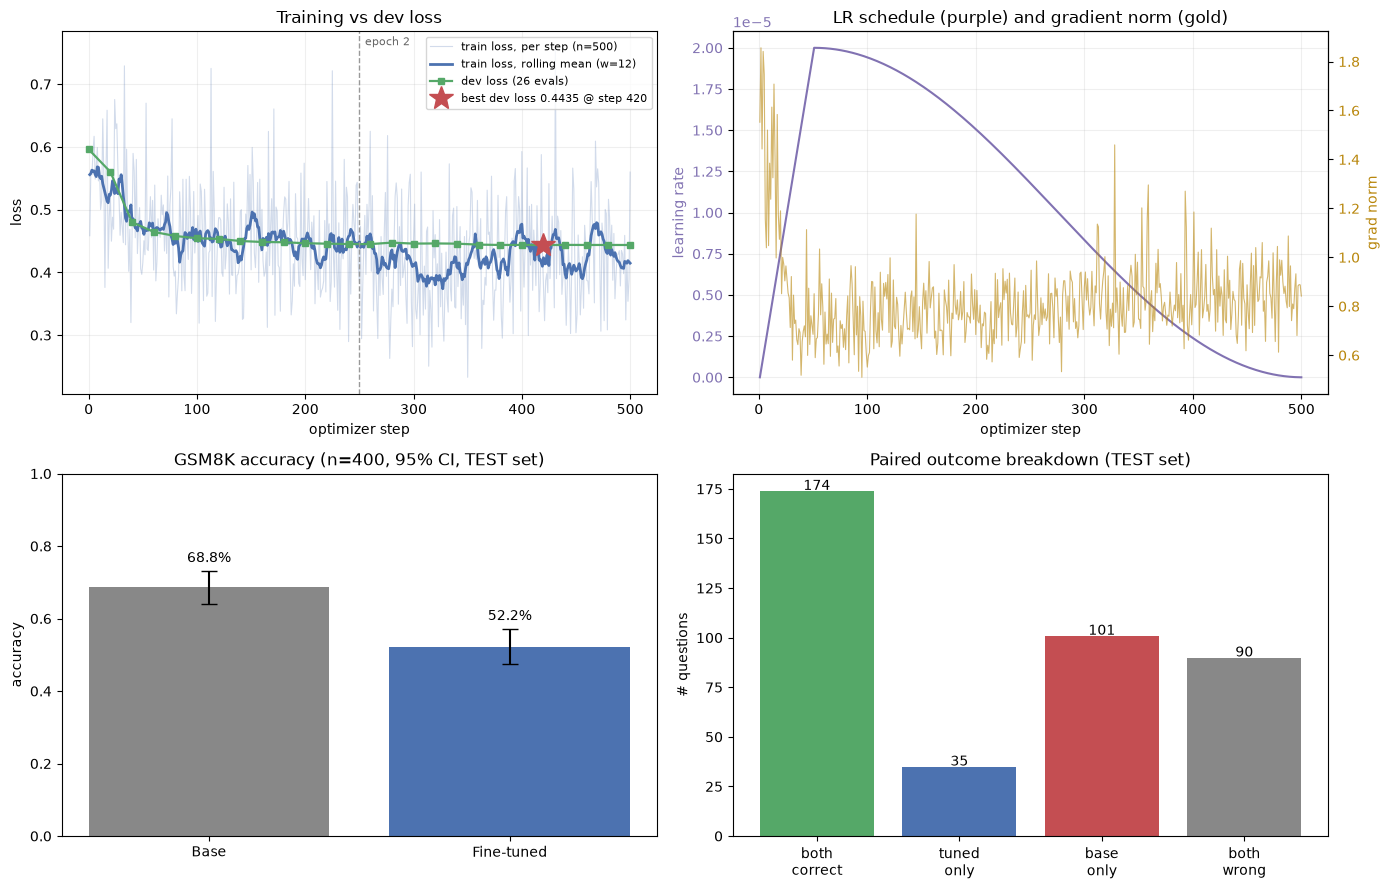

In [33]:
log_history = pd.DataFrame(trainer.state.log_history)
train_log = log_history.dropna(subset=["loss"]) if "loss" in log_history else pd.DataFrame()
eval_log  = log_history.dropna(subset=["eval_loss"]) if "eval_loss" in log_history else pd.DataFrame()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax_loss, ax_sched, ax_acc, ax_pair = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

# --- 1. loss ---------------------------------------------------------------
# logging_steps=1 means every train point is a single-batch loss estimate, so the
# raw series is genuinely noisy. Plot both: raw faint, rolling mean solid.
if not train_log.empty:
    win = max(1, len(train_log) // 40)
    ax_loss.plot(train_log["step"], train_log["loss"], color="#4c72b0", lw=0.8, alpha=0.25,
                 label=f"train loss, per step (n={len(train_log)})")
    ax_loss.plot(train_log["step"],
                 train_log["loss"].rolling(win, center=True, min_periods=1).mean(),
                 color="#4c72b0", lw=2.0, label=f"train loss, rolling mean (w={win})")
if not eval_log.empty:
    ax_loss.plot(eval_log["step"], eval_log["eval_loss"], marker="s", ms=4, lw=1.6,
                 color="#55a868", label=f"dev loss ({len(eval_log)} evals)")
    best_row = eval_log.loc[eval_log["eval_loss"].idxmin()]
    ax_loss.plot([best_row["step"]], [best_row["eval_loss"]], marker="*", ms=18, ls="none",
                 color="#c44e52", zorder=5,
                 label=f"best dev loss {best_row['eval_loss']:.4f} @ step {int(best_row['step'])}")
for e in range(1, int(EPOCHS)):
    ax_loss.axvline(e * steps_per_epoch, color="#999999", ls="--", lw=1)
    ax_loss.annotate(f"epoch {e + 1}", xy=(e * steps_per_epoch, 1.0), xycoords=("data", "axes fraction"),
                     xytext=(4, -10), textcoords="offset points", fontsize=8, color="#666666")
ax_loss.set(xlabel="optimizer step", ylabel="loss", title="Training vs dev loss")
ax_loss.legend(fontsize=8, loc="best")
ax_loss.grid(alpha=0.2)

# --- 2. schedule and gradient norm -----------------------------------------
if not train_log.empty and "learning_rate" in train_log:
    ax_sched.plot(train_log["step"], train_log["learning_rate"], color="#8172b2", lw=1.5)
    ax_sched.set_ylabel("learning rate", color="#8172b2")
    ax_sched.tick_params(axis="y", labelcolor="#8172b2")
    if "grad_norm" in train_log:
        ax_grad = ax_sched.twinx()
        ax_grad.plot(train_log["step"], train_log["grad_norm"], color="#b8860b", lw=0.8, alpha=0.6)
        ax_grad.set_ylabel("grad norm", color="#b8860b")
        ax_grad.tick_params(axis="y", labelcolor="#b8860b")
ax_sched.set(xlabel="optimizer step", title="LR schedule (purple) and gradient norm (gold)")
ax_sched.grid(alpha=0.2)

# --- 3. accuracy ------------------------------------------------------------
labels = ["Base", "Fine-tuned"]
accs = [base_acc, tuned_acc]
lowers = [base_acc - base_lo, tuned_acc - tuned_lo]
uppers = [base_hi - base_acc, tuned_hi - tuned_acc]
ax_acc.bar(labels, accs, yerr=[lowers, uppers], capsize=6, color=["#888888", "#4c72b0"])
ax_acc.set(ylabel="accuracy", ylim=(0, 1),
           title=f"GSM8K accuracy (n={len(paired)}, 95% CI, TEST set)")
for i, (a, hi) in enumerate(zip(accs, [base_hi, tuned_hi])):
    ax_acc.text(i, hi + 0.025, f"{a:.1%}", ha="center")   # above the CI cap, not the bar top

# --- 4. paired outcomes -----------------------------------------------------
outcome_labels = ["both\ncorrect", "tuned\nonly", "base\nonly", "both\nwrong"]
outcome_vals = [both_correct, tuned_only, base_only, both_wrong]
ax_pair.bar(outcome_labels, outcome_vals, color=["#55a868", "#4c72b0", "#c44e52", "#888888"])
ax_pair.set(ylabel="# questions", title="Paired outcome breakdown (TEST set)")
for i, v in enumerate(outcome_vals):
    ax_pair.text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
fig_path = os.path.join(RESULTS_DIR, "comparison.png")
plt.savefig(fig_path, dpi=150)
print(f"Saved figure to {fig_path}")
plt.show()

## 18. Qualitative disagreements

The full generations for every question where the two models disagreed --
these are the individual cases underlying the paired statistics above, and
worth reading before trusting any headline number.


In [34]:
disagreements = paired[paired.base_correct != paired.tuned_correct]
print(f"{len(disagreements)} questions where base and tuned disagreed\n")

for i in disagreements.head(6).index:
    row = paired.loc[i]
    print(f"Q: {row.question}")
    print(f"   gold  : {row.gold}")
    print(f"   base  : {base_df.loc[i, 'pred_value']}  "
          f"({'correct' if row.base_correct else 'wrong'})")
    print(f"   tuned : {tuned_df.loc[i, 'pred_value']}  "
          f"({'correct' if row.tuned_correct else 'wrong'})")
    print()


136 questions where base and tuned disagreed

Q: Four children are playing together—Akbar, Alessandro, Helene, and Wilfred. Helene is twice as old as the average age of the group, and the total age of the children is 20. If Akbar is 3 years old and Alessandro is 4 years old, calculate the age of Wilfred.
   gold  : 3
   base  : 3  (correct)
   tuned : 6.5  (wrong)

Q: Hannah needs to drink 100 ml of water for every 200 calories she burns. She spends 2 hours doing aerobics, which burns 500 calories/hour, and 1 hour running, which burns 600 calories/hour. How many ml of water does she need to drink?
   gold  : 800
   base  : 800  (correct)
   tuned : 80  (wrong)

Q: Griffin had 24 french fries, but Kyle took 5 of them.  Billy took twice as many as Kyle.  Ginger gave Griffin a handful of her fries, and then Colby took from Griffin 3 less than the number of fries that Kyle had taken.  If in the end Griffin had 27 fries, how many fries did Ginger give Griffin?
   gold  : 20
   base  : 20  (

## 19. Loading the saved model later

If `SAVE_MERGED` was on, the merged model can be loaded on its own -- no adapter directory, no
`peft` import required. Otherwise (the default), the same result is reproduced by loading the base
model and attaching the saved adapter, which is exactly what Section 14 already does.

In [35]:
from transformers import pipeline

if SAVE_MERGED and os.path.isdir(MERGED_DIR) and os.listdir(MERGED_DIR):
    loaded_tokenizer = AutoTokenizer.from_pretrained(MERGED_DIR)
    loaded_model = AutoModelForCausalLM.from_pretrained(
        MERGED_DIR, dtype=COMPUTE_DTYPE, device_map={"": 0}
    )
else:
    from peft import PeftModel
    loaded_tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
    loaded_base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID, dtype=COMPUTE_DTYPE, device_map={"": 0}
    )
    loaded_model = PeftModel.from_pretrained(loaded_base, ADAPTER_DIR)

# Set generation params directly on the model's own generation_config rather than
# passing a separate GenerationConfig (or max_new_tokens=/do_sample=) into pipeline()
# or the pipeline call -- passing generation_config as a pipeline kwarg collides with
# transformers' own internal use of that same keyword (Pipeline.__init__ forwards it
# into model._prepare_generation_config(generation_config=..., **kwargs), which still
# has generation_config in kwargs, raising "multiple values for keyword argument").
loaded_model.generation_config.max_length = None
loaded_model.generation_config.max_new_tokens = MAX_NEW_TOKENS
loaded_model.generation_config.do_sample = False
solver = pipeline("text-generation", model=loaded_model, tokenizer=loaded_tokenizer)

demo_question = (
    "Mark has a box of 40 chocolates. He eats 5, gives half of the remainder "
    "to his sister, then buys 10 more the next day. How many does Mark have now?"
)
demo_prompt = to_chat_example(demo_question)
result = solver(demo_prompt)[0]["generated_text"]
print(result[len(demo_prompt):])

Loading weights: 100%|██████████| 338/338 [00:01<00:00, 274.32it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


He gave away 20 because 40 / 2 = 20
He had 20 left after eating 5 so he has 30.
Then he bought another 10 for 40 total.
#### 40


## 20. Conclusion -- how to read the result

Compare `tuned_acc - base_acc` against the McNemar p-value and the discordance rate printed in
Section 16, not just against zero:

- **A significant gain** (`p < 0.05`, positive delta): before trusting it, check whether it survives
  on the subset where *both* models emitted a `#### N` line. If the gain only shows up when
  including generations that needed the last-number fallback, some of it may be an artifact of the
  fine-tuned model becoming easier to parse, not more accurate.
- **No significant change** (`p >= 0.05`): this is a realistic best case, not a failed experiment --
  it means high `####` compliance was achieved without a real accuracy cost. With `N_EVAL=400`, the
  discordance-dependent minimum detectable difference is roughly 7-10 percentage points -- a
  measured swing smaller than that is indistinguishable from noise at this sample size. Raising
  `N_EVAL` (Section 3) tightens this at the cost of longer eval runs.
- **A significant regression** (`p < 0.05`, negative delta): look at `mean new tokens` and
  `mean reasoning lines` in Section 16's table and the qualitative examples in Section 18. A prior
  run at 3 epochs and a 5x-higher learning rate showed exactly this mechanism: GSM8K's terse gold
  rationales taught the model to cut its own reasoning short (275 -> 86 mean tokens, 18.5 -> 4.6
  reasoning lines), and that -- not a parsing/extraction problem -- was the entire cause of the
  accuracy drop. If this run regresses too, despite the much smaller drift budget (`EPOCHS=1`,
  lower `LEARNING_RATE`/`LORA_ALPHA`), the next lever to pull is loss-based checkpoint selection
  itself: dev loss rewards imitating the terse gold text, which is the same behavior that causes the
  collapse, so it can select a damaged checkpoint even when a less-loss-optimal one would have
  scored higher on accuracy. The cheapest test is comparing the loss-selected adapter against the
  final-step adapter on `dev` before deciding whether a different target-module set (e.g. dropping
  `gate_proj`/`up_proj`/`down_proj`) is worth a separate run.

Standing caveats regardless of outcome: GSM8K is a widely-used SFT dataset and
`Qwen2.5-1.5B-Instruct` has almost certainly seen similar data during its own instruction tuning, so
this experiment measures format/style adaptation more than new mathematical capability; decoding is
greedy (single deterministic sample per question, not an average over multiple attempts); and this
is one training run with one seed.